In [1]:
%load_ext tensorboard
#/root/medair_skynet_01/output-2023-01-20-ood-pretraining/ood_pretraining/updated_vsa/

In [2]:
import pandas as pd
import numpy as np
import json
from glob import glob
import matplotlib.pyplot as plt

In [3]:
# VSA Warmup Tuning
# file_name = '/root/output/hp_tuning_vsa_warmup/2023_02_19-033134_ignore_words_snomed_all/output/*/*/trainer_state.json'
file_name = '/root/medair_skynet_01/output-2023-01-20-ood-pretraining/mortality_finetune_experiments/2023_03_07-134119_group_vectors_words_rv_snomed_all/output/*/trainer_state.json'

file_model_type = file_name.split('/')[5]
filepaths = glob(file_name)
file_model_type

'2023_03_07-134119_group_vectors_words_rv_snomed_all'

In [4]:
trainer_state_dict = {}

for file in filepaths:
    with open(file) as f:
        data = json.load(f)
        trainer_state_dict[file] = {'json': data, 'vsa_type': file_model_type}

trainer_state_dict

{'/root/medair_skynet_01/output-2023-01-20-ood-pretraining/mortality_finetune_experiments/2023_03_07-134119_group_vectors_words_rv_snomed_all/output/checkpoint-7742/trainer_state.json': {'json': {'best_metric': None,
   'best_model_checkpoint': None,
   'epoch': 49.0,
   'global_step': 7742,
   'is_hyper_param_search': False,
   'is_local_process_zero': True,
   'is_world_process_zero': True,
   'log_history': [{'accuracy': 0.3611111111111111, 'epoch': 0, 'step': 0},
    {'accuracy': 0.5133333333333333, 'epoch': 0.01, 'step': 1},
    {'accuracy': 0.5533333333333333, 'epoch': 0.01, 'step': 2},
    {'accuracy': 0.6363636363636364, 'epoch': 0.02, 'step': 3},
    {'accuracy': 0.5944444444444444, 'epoch': 0.03, 'step': 4},
    {'accuracy': 0.6, 'epoch': 0.03, 'step': 5},
    {'accuracy': 0.5, 'epoch': 0.04, 'step': 6},
    {'accuracy': 0.49230769230769234, 'epoch': 0.04, 'step': 7},
    {'accuracy': 0.6588235294117647, 'epoch': 0.05, 'step': 8},
    {'accuracy': 0.6866666666666666, 'epoch':

In [23]:

import os

results = {}

finetune_task = "mortality_finetune_experiments"
#finetune_task = "disease_finetune_experiments"

for file_folder in os.listdir("/root/medair_skynet_01/output-2023-01-20-ood-pretraining/" + finetune_task + "/"):
    # Get most recent runs
    if file_folder.startswith("2023_03"):
        files = glob("/root/medair_skynet_01/output-2023-01-20-ood-pretraining/" + finetune_task + "/" + file_folder + "/output/*/trainer_state.json")
        file = files[-1] 
        run = file.split('/')[-4]

        checkpoint = file.split('/')[-2]
        results.setdefault(run, {})

        # Grab all train losses
        with open(file, "r") as f:
            data = json.load(f)

        # Grab all train losses up to step 10000
        for log in data['log_history']:
            if log.get('loss') is not None:
                results[run].setdefault('train_loss', []).append(log['loss'])
                results[run].setdefault('train_steps', []).append(log['step'])
            if log.get('accuracy') is not None:
                results[run].setdefault('train_acc', []).append(log['accuracy'])
                results[run].setdefault('train_acc_steps', []).append(log['step'])
            if log.get('eval_accuracy') is not None:
                results[run].setdefault('eval_accuracy', []).append(log['eval_accuracy'])
                results[run].setdefault('eval_loss', []).append(log['eval_loss'])
                results[run].setdefault('eval_step', []).append(log['step'])


In [7]:
selected_types = ["no_vsa", "ignore_words_snomed_all", "ignore_words_rv_snomed_all", "group_vectors_words_rv_snomed_all"]
selected_results = {}
#no_pre = {}
#print(run + "highest eval accuracy: " + str(np.max(data['eval_accuracy'])))

for run in results.keys():
    for selected_type in selected_types:
        if selected_type in run and int(run[8:10]) >= 13:
            selected_results.setdefault(selected_type,{})
            selected_results[selected_type].setdefault(run, results[run])
            selected_results[selected_type].setdefault("best_acc_loc", (np.amax(results[run]['eval_accuracy'])))
        # if int(run[9])<5:
        #     selected_results[run]['method'] ='Pretraining-Unbalanced'
        # elif int(run[9])<6:
        #     selected_results[run]['method'] ='Pretraining-Balanced'
            
        # elif int(run[9])<7:
        #     selected_results[run]['method'] ='No Pretraining-Unbalanced'
        #     #no_pre.setdefault(run, results[run])
            
        # else:
        #     selected_results[run]['method'] ='No Pretraining-Balanced'
                

In [45]:
selected_results['group_vectors_words_rv_snomed_all']
selected_results['no_vsa']


{'2023_03_10-144650_no_vsa': {'train_acc': [0.0625,
   0.0875,
   0.1125,
   0.0875,
   0.1625,
   0.1625,
   0.15,
   0.125,
   0.1625,
   0.2125,
   0.1375,
   0.1375,
   0.1875,
   0.175,
   0.225,
   0.1625,
   0.175,
   0.3375,
   0.2125,
   0.25,
   0.175,
   0.2875,
   0.2875,
   0.275,
   0.2625,
   0.2875,
   0.225,
   0.2625,
   0.3,
   0.325,
   0.2375,
   0.2125,
   0.175,
   0.3375,
   0.275,
   0.3125,
   0.375,
   0.275,
   0.2125,
   0.3125,
   0.3125,
   0.275,
   0.25,
   0.35,
   0.275,
   0.325,
   0.25,
   0.2875,
   0.2625,
   0.2375,
   0.3,
   0.425,
   0.3375,
   0.3625,
   0.3,
   0.3,
   0.42857142857142855,
   0.5,
   0.125,
   0.125,
   0.625,
   0.5,
   0.5,
   0.125,
   0.125,
   0.5,
   0.125,
   0.25,
   0.25,
   0.25,
   0.125,
   0.25,
   0.5,
   0.375,
   0.125,
   0.5,
   0.25,
   0.25,
   0.5,
   0.5,
   0.375,
   0.125,
   0.375,
   0.25,
   0.5,
   0.125,
   0.2,
   0.3,
   0.2875,
   0.3125,
   0.2625,
   0.3125,
   0.3125,
   0.35,
   0.3375,
 

Run: 2023_03_13-215136_no_vsa
	 Highest eval accuracy: 0.9948930470090837
	 At: 44
Run: 2023_03_13-225011_no_vsa
	 Highest eval accuracy: 0.9962545257813475
	 At: 48
Run: 2023_03_13-234909_no_vsa
	 Highest eval accuracy: 0.9952855772038883
	 At: 46
Run: 2023_03_15-015958_no_vsa
	 Highest eval accuracy: 0.9787958006556289
	 At: 44
Run: 2023_03_15-025846_no_vsa
	 Highest eval accuracy: 0.9749781423040094
	 At: 45
Run: 2023_03_15-035750_no_vsa
	 Highest eval accuracy: 0.9817796081367778
	 At: 45


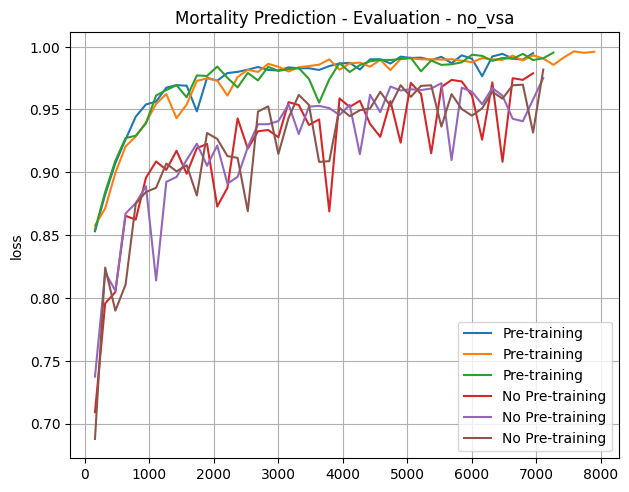

Run: 2023_03_14-004745_ignore_words_snomed_all
	 Highest eval accuracy: 0.9945180447693011
	 At: 48
Run: 2023_03_14-032505_ignore_words_snomed_all
	 Highest eval accuracy: 0.9947802311611914
	 At: 48
Run: 2023_03_14-060422_ignore_words_snomed_all
	 Highest eval accuracy: 0.9949851644448159
	 At: 49
Run: 2023_03_15-045702_ignore_words_snomed_all
	 Highest eval accuracy: 0.9749780325536633
	 At: 49
Run: 2023_03_15-073437_ignore_words_snomed_all
	 Highest eval accuracy: 0.9712789392742841
	 At: 49
Run: 2023_03_15-101227_ignore_words_snomed_all
	 Highest eval accuracy: 0.974832563750572
	 At: 50


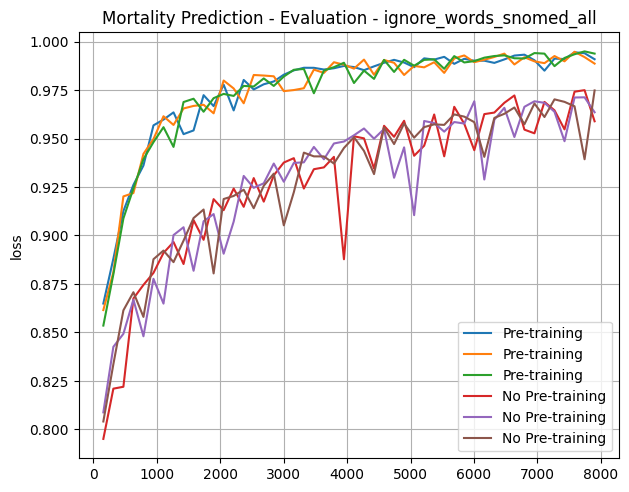

Run: 2023_03_14-084325_ignore_words_rv_snomed_all
	 Highest eval accuracy: 0.9955702285929208
	 At: 46
Run: 2023_03_14-112005_ignore_words_rv_snomed_all
	 Highest eval accuracy: 0.9949264120088893
	 At: 43
Run: 2023_03_14-135855_ignore_words_rv_snomed_all
	 Highest eval accuracy: 0.9952953911486739
	 At: 42
Run: 2023_03_15-125020_ignore_words_rv_snomed_all
	 Highest eval accuracy: 0.9755954623466868
	 At: 41
Run: 2023_03_15-152943_ignore_words_rv_snomed_all
	 Highest eval accuracy: 0.9719024065838148
	 At: 42
Run: 2023_03_15-181604_ignore_words_rv_snomed_all
	 Highest eval accuracy: 0.9724140783324372
	 At: 46


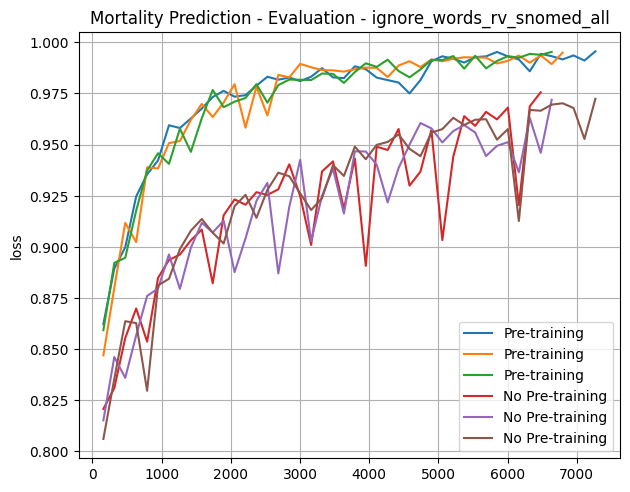

Run: 2023_03_16-044445_group_vectors_words_rv_snomed_all
	 Highest eval accuracy: 0.9718633722145574
	 At: 48
Run: 2023_03_16-072134_group_vectors_words_rv_snomed_all
	 Highest eval accuracy: 0.9773224833739519
	 At: 49
Run: 2023_03_16-095844_group_vectors_words_rv_snomed_all
	 Highest eval accuracy: 0.9730982914908727
	 At: 47


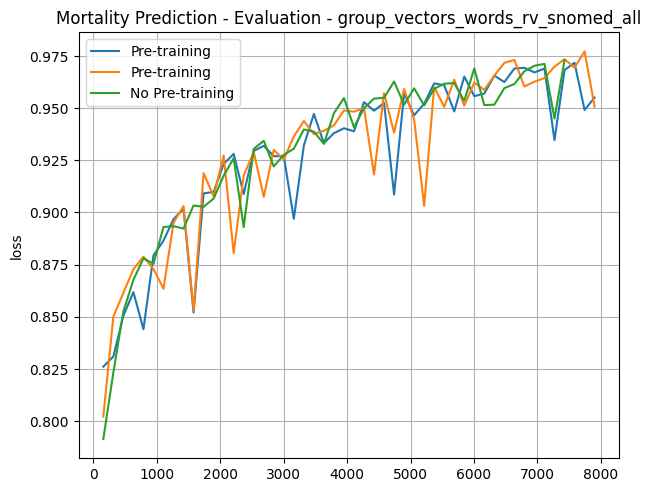

In [21]:
for selected_type in selected_types:
    fig, ax = plt.subplots()

    sorted_runs = sorted([*selected_results[selected_type]])
    for i, run in enumerate(sorted_runs):
        # if i < len(sorted_runs/2):
        #     pretrain = "Pre-training"
        # else:
        #     pretrain= "No Pre-training"
        pretrain = "Pre-training" if i < len(sorted_runs)/2 else "No Pre-training"
        data = results[run]
        print("Run: " + run)
        print("\t Highest eval accuracy: " + str(np.max(data['eval_accuracy'])))
        print("\t At: " + str(np.argmax(data['eval_accuracy']) + 1))
        ax.set_ylabel("loss")
        #ax.plot(data['train_steps'], data['train_loss'], label=run)
        #ax.plot(data['train_acc_steps'], data['train_acc'], label=run)
        #ax.plot(data['eval_step'], data['eval_loss'], label=pretrain)
        #ax.twinx()
        ax.plot(data['eval_step'], data['eval_accuracy'], label=pretrain)
        
        #ax.set_ylim(4, 11)
    plt.legend()
    plt.grid('on')
    plt.tight_layout()
    plt.title("Mortality Prediction - Evaluation - " + selected_type)
    #plt.title("Disease Prediction - Evaluation - " + selected_type)
    plt.show()

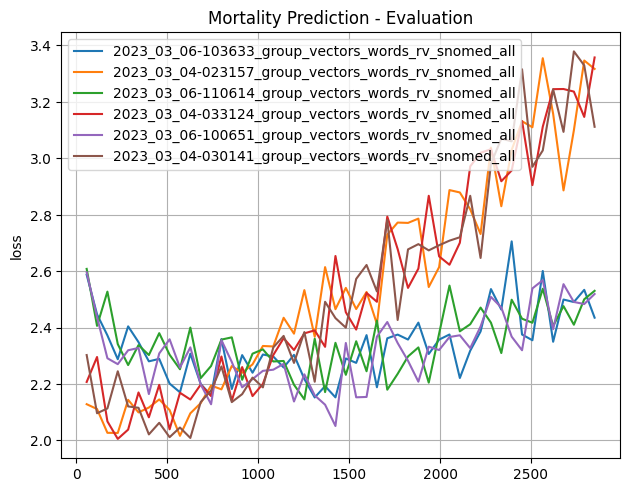

In [26]:
fig, ax = plt.subplots()


for run in results.keys():
    if "group_vectors_words_rv" in run:
        data = results[run]
        ax.set_ylabel("loss")
        #ax.plot(data['train_steps'], data['train_loss'], label=run)
        #ax.plot(data['train_acc_steps'], data['train_acc'], label=run)
        ax.plot(data['eval_step'], data['eval_loss'], label=run)
        #ax.plot(data['eval_step'], data['eval_accuracy'], label=run)
        #ax.set_ylim(4, 11)
plt.legend()
plt.grid('on')
plt.tight_layout()
#plt.title("Mortality Prediction - Evaluation")
plt.title("Disease Prediction - Evaluation")
plt.show()